In [26]:
# compile results
import pickle

homedir = "/mnt/mirabelle/az6922_homedir/"
cm_list = ["unv1","prv1"] #,"cluster_a","cluster_b","cluster_c"]
load_list_dict = dict()
load_list_dict["unv1"] = range(1,11)
load_list_dict["prv1"] = range(1,11)
load_list_dict["cluster_a"] = range(3,31,3)
load_list_dict["cluster_b"] = range(4,41,4)
load_list_dict["cluster_c"] = range(5,51,5)
seed_list = [1,2,3,4,5]
scheme_list = ["dringsu2","dringsu2e","leafspine","rrgsu2","df2augalg","dringecmp","dringwcmpecmp","dringfatpaths","dringfhi","dringracke1four"]


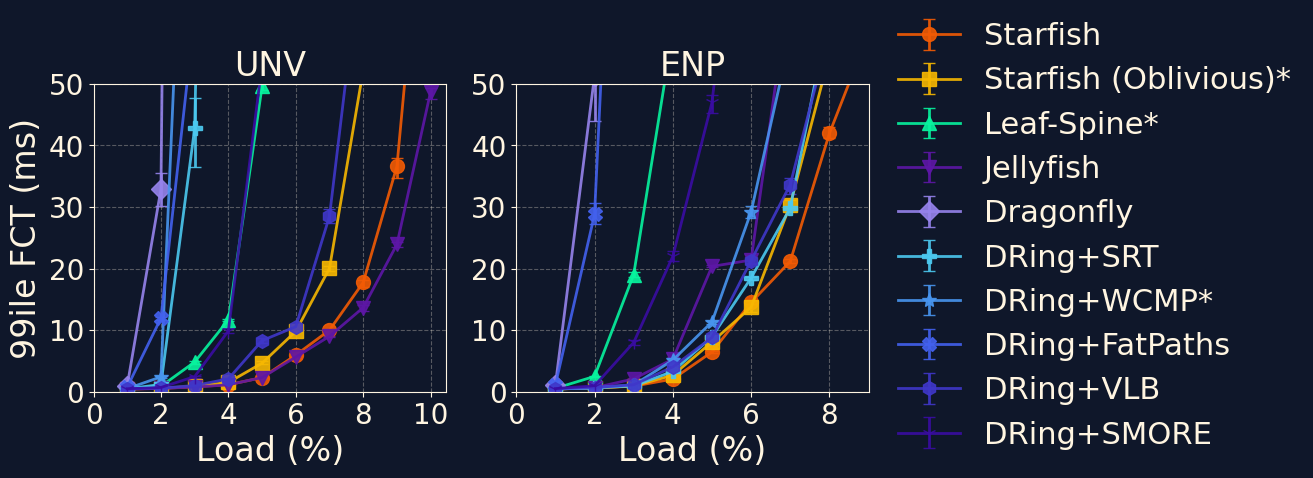

In [32]:
import matplotlib.pyplot as plt
import numpy as np

plottitledict = {"unv1":"UNV","prv1":"ENP","cluster_a":"DB","cluster_b":"WS","cluster_c":"HD"}
plotlabeldict = {"dringsu2":"Starfish","dringsu2e":"Starfish (Oblivious)*","leafspine":"Leaf-Spine*","df2augalg":"Dragonfly","rrgsu2":"Jellyfish","dringecmp":"DRing+SRT","dringwcmpecmp":"DRing+WCMP*","dringfatpaths":"DRing+FatPaths","dringfhi":"DRing+VLB","dringracke1four":"DRing+SMORE"}
plotxlimdict = {"unv1":None,"prv1":9,"cluster_a":25,"cluster_b":35,"cluster_c":40}
plotmarkers = ['o', 's', '^', 'v', 'D', 'P', '*', 'X', 'h', '1']
plotcolordict = {"dringsu2":"#f35b04","dringsu2e":"#f7b801","leafspine":"#07f49e","df2augalg":"#9683ec","rrgsu2":"#5d16a6","dringecmp":"#4cc9f0","dringwcmpecmp":"#4895ef","dringfatpaths":"#4361ee","dringfhi":"#3f37c9","dringracke1four":"#3a0ca3"}
plotxticksdict = {"unv1":[0,2,4,6,8,10],"prv1":[0,2,4,6,8],"cluster_a":[0,5,10,15,20,25],"cluster_b":[0,5,10,15,20,25,30,35],"cluster_c":[0,10,20,30,40]}

bg_color = "#0F172A"
text_color = "#FFF5E1"

plotdatadict = dict()
sumfile = "fct_summary.txt"

with open(sumfile, "r") as f:
    for line in f:
        tokens = line.split()
        outfile = tokens[0]
        outfiletokens = outfile.split("/")
        cm = outfiletokens[0]

        avg = float(tokens[1])
        p50 = float(tokens[2])
        p99 = float(tokens[3])
        p9999 = float(tokens[4])

        if cm not in plotdatadict:
            plotdatadict[cm] = dict()

        plotdatadict[cm][outfile] = p99


nr = 1
nc = len(cm_list)

fig, axs = plt.subplots(nr, nc, figsize=(nc * 5, nr * 4))

fig.patch.set_facecolor(bg_color)

if nc == 1:
    axs = [axs]

for ic, cm in enumerate(cm_list):
    ax = axs[ic]
    ax.set_facecolor(bg_color)

    for isc, scheme in enumerate(scheme_list):
        fct_list = []

        for load in load_list_dict[cm]:
            fct_list_allseeds = []

            for seed in seed_list:
                outfile = f"{cm}/outfiles/{scheme}_load{load}_seed{seed}.out"
                p99 = plotdatadict[cm][outfile]
                fct_list_allseeds.append(p99)

            fct_list.append(fct_list_allseeds)

        means = [sum(x) / len(x) for x in fct_list]
        yerr_lower = [sum(x) / len(x) - min(x) for x in fct_list]
        yerr_upper = [max(x) - sum(x) / len(x) for x in fct_list]

        label = plotlabeldict[scheme] if ic == 0 else None

        ax.errorbar(
            load_list_dict[cm],
            means,
            yerr=[yerr_lower, yerr_upper],
            alpha=0.9,
            markersize=10,
            marker=plotmarkers[isc],
            color=plotcolordict[scheme],
            capsize=4,
            linewidth=2,
            label=label,
        )

    ax.set_xlabel("Load (%)", fontsize=24, color=text_color)

    if ic == 0:
        ax.set_ylabel("99ile FCT (ms)", fontsize=24, color=text_color)

    ax.set_xlim(0, plotxlimdict[cm])
    ax.set_ylim(0, 50)
    ax.set_xticks(plotxticksdict[cm])
    ax.set_title(plottitledict[cm], fontsize=24, color=text_color)

    ax.tick_params(axis="both", labelsize=20, colors=text_color)

    ax.grid(True, linestyle="--", alpha=0.3, color=text_color)

    for spine in ax.spines.values():
        spine.set_color(text_color)

legend = fig.legend(
    loc="center right",
    ncol=1,
    fontsize=22,
    bbox_to_anchor=(1.35, 0.5),
    frameon=False,
)

for text in legend.get_texts():
    text.set_color(text_color)

plt.savefig(f"talk_capacity_full.pdf", dpi=600, bbox_inches='tight')

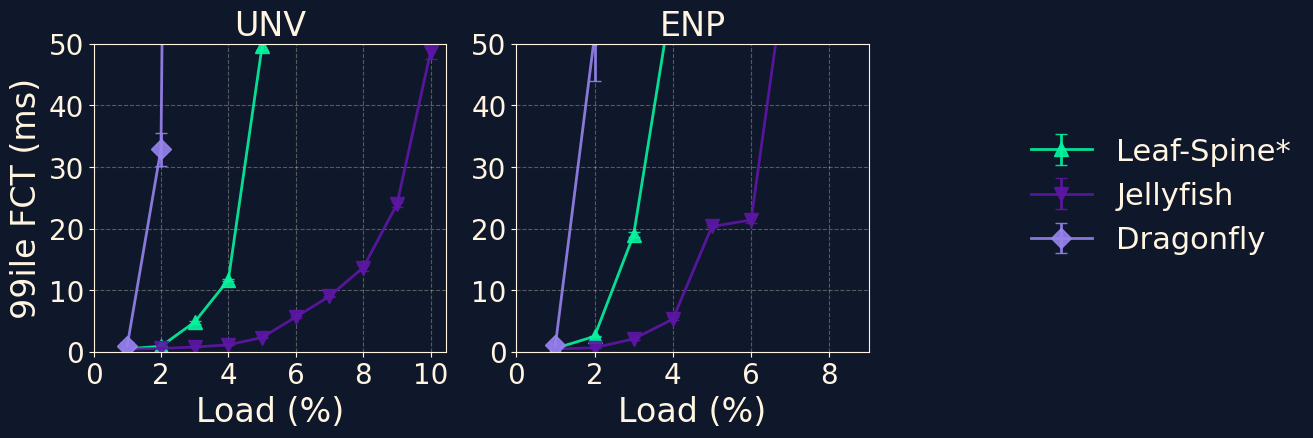

In [36]:
import matplotlib.pyplot as plt
import numpy as np

my_scheme_list = ["leafspine","rrgsu2","df2augalg"]

plottitledict = {"unv1":"UNV","prv1":"ENP","cluster_a":"DB","cluster_b":"WS","cluster_c":"HD"}
plotlabeldict = {"dringsu2":"Starfish","dringsu2e":"Starfish (Oblivious)*","leafspine":"Leaf-Spine*","df2augalg":"Dragonfly","rrgsu2":"Jellyfish","dringecmp":"DRing+SRT","dringwcmpecmp":"DRing+WCMP*","dringfatpaths":"DRing+FatPaths","dringfhi":"DRing+VLB","dringracke1four":"DRing+SMORE"}
plotxlimdict = {"unv1":None,"prv1":9,"cluster_a":25,"cluster_b":35,"cluster_c":40}
plotmarkers = ['^', 'v', 'D', 'P', '*', 'X', 'h', '1']
plotcolordict = {"dringsu2":"#f35b04","dringsu2e":"#f7b801","leafspine":"#07f49e","df2augalg":"#9683ec","rrgsu2":"#5d16a6","dringecmp":"#4cc9f0","dringwcmpecmp":"#4895ef","dringfatpaths":"#4361ee","dringfhi":"#3f37c9","dringracke1four":"#3a0ca3"}
plotxticksdict = {"unv1":[0,2,4,6,8,10],"prv1":[0,2,4,6,8],"cluster_a":[0,5,10,15,20,25],"cluster_b":[0,5,10,15,20,25,30,35],"cluster_c":[0,10,20,30,40]}

bg_color = "#0F172A"
text_color = "#FFF5E1"

plotdatadict = dict()
sumfile = "fct_summary.txt"

with open(sumfile, "r") as f:
    for line in f:
        tokens = line.split()
        outfile = tokens[0]
        outfiletokens = outfile.split("/")
        cm = outfiletokens[0]

        avg = float(tokens[1])
        p50 = float(tokens[2])
        p99 = float(tokens[3])
        p9999 = float(tokens[4])

        if cm not in plotdatadict:
            plotdatadict[cm] = dict()

        plotdatadict[cm][outfile] = p99


nr = 1
nc = len(cm_list)

fig, axs = plt.subplots(nr, nc, figsize=(nc * 5, nr * 4))

fig.patch.set_facecolor(bg_color)

if nc == 1:
    axs = [axs]

for ic, cm in enumerate(cm_list):
    ax = axs[ic]
    ax.set_facecolor(bg_color)

    for isc, scheme in enumerate(my_scheme_list):
        fct_list = []

        for load in load_list_dict[cm]:
            fct_list_allseeds = []

            for seed in seed_list:
                outfile = f"{cm}/outfiles/{scheme}_load{load}_seed{seed}.out"
                p99 = plotdatadict[cm][outfile]
                fct_list_allseeds.append(p99)

            fct_list.append(fct_list_allseeds)

        means = [sum(x) / len(x) for x in fct_list]
        yerr_lower = [sum(x) / len(x) - min(x) for x in fct_list]
        yerr_upper = [max(x) - sum(x) / len(x) for x in fct_list]

        label = plotlabeldict[scheme] if ic == 0 else None

        ax.errorbar(
            load_list_dict[cm],
            means,
            yerr=[yerr_lower, yerr_upper],
            alpha=0.9,
            markersize=10,
            marker=plotmarkers[isc],
            color=plotcolordict[scheme],
            capsize=4,
            linewidth=2,
            label=label,
        )

    ax.set_xlabel("Load (%)", fontsize=24, color=text_color)

    if ic == 0:
        ax.set_ylabel("99ile FCT (ms)", fontsize=24, color=text_color)

    ax.set_xlim(0, plotxlimdict[cm])
    ax.set_ylim(0, 50)
    ax.set_xticks(plotxticksdict[cm])
    ax.set_title(plottitledict[cm], fontsize=24, color=text_color)

    ax.tick_params(axis="both", labelsize=20, colors=text_color)

    ax.grid(True, linestyle="--", alpha=0.3, color=text_color)

    for spine in ax.spines.values():
        spine.set_color(text_color)

legend = fig.legend(
    loc="center right",
    ncol=1,
    fontsize=22,
    bbox_to_anchor=(1.35, 0.5),
    frameon=False,
)

for text in legend.get_texts():
    text.set_color(text_color)

plt.savefig(f"talk_capacity_topology.pdf", dpi=600, bbox_inches='tight')

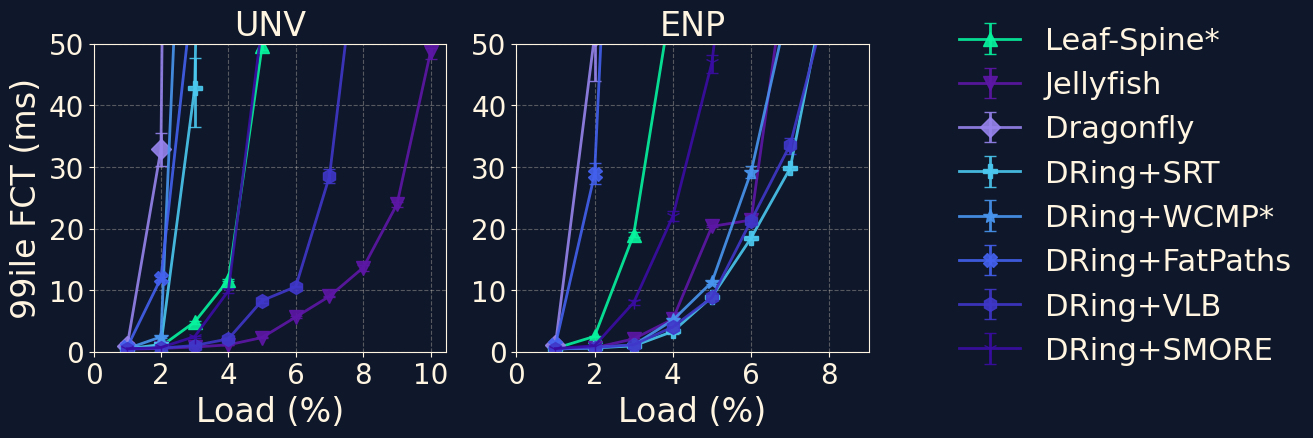

In [37]:
import matplotlib.pyplot as plt
import numpy as np

my_scheme_list = ["leafspine","rrgsu2","df2augalg","dringecmp","dringwcmpecmp","dringfatpaths","dringfhi","dringracke1four"]

plottitledict = {"unv1":"UNV","prv1":"ENP","cluster_a":"DB","cluster_b":"WS","cluster_c":"HD"}
plotlabeldict = {"dringsu2":"Starfish","dringsu2e":"Starfish (Oblivious)*","leafspine":"Leaf-Spine*","df2augalg":"Dragonfly","rrgsu2":"Jellyfish","dringecmp":"DRing+SRT","dringwcmpecmp":"DRing+WCMP*","dringfatpaths":"DRing+FatPaths","dringfhi":"DRing+VLB","dringracke1four":"DRing+SMORE"}
plotxlimdict = {"unv1":None,"prv1":9,"cluster_a":25,"cluster_b":35,"cluster_c":40}
plotmarkers = ['^', 'v', 'D', 'P', '*', 'X', 'h', '1']
plotcolordict = {"dringsu2":"#f35b04","dringsu2e":"#f7b801","leafspine":"#07f49e","df2augalg":"#9683ec","rrgsu2":"#5d16a6","dringecmp":"#4cc9f0","dringwcmpecmp":"#4895ef","dringfatpaths":"#4361ee","dringfhi":"#3f37c9","dringracke1four":"#3a0ca3"}
plotxticksdict = {"unv1":[0,2,4,6,8,10],"prv1":[0,2,4,6,8],"cluster_a":[0,5,10,15,20,25],"cluster_b":[0,5,10,15,20,25,30,35],"cluster_c":[0,10,20,30,40]}

bg_color = "#0F172A"
text_color = "#FFF5E1"

plotdatadict = dict()
sumfile = "fct_summary.txt"

with open(sumfile, "r") as f:
    for line in f:
        tokens = line.split()
        outfile = tokens[0]
        outfiletokens = outfile.split("/")
        cm = outfiletokens[0]

        avg = float(tokens[1])
        p50 = float(tokens[2])
        p99 = float(tokens[3])
        p9999 = float(tokens[4])

        if cm not in plotdatadict:
            plotdatadict[cm] = dict()

        plotdatadict[cm][outfile] = p99


nr = 1
nc = len(cm_list)

fig, axs = plt.subplots(nr, nc, figsize=(nc * 5, nr * 4))

fig.patch.set_facecolor(bg_color)

if nc == 1:
    axs = [axs]

for ic, cm in enumerate(cm_list):
    ax = axs[ic]
    ax.set_facecolor(bg_color)

    for isc, scheme in enumerate(my_scheme_list):
        fct_list = []

        for load in load_list_dict[cm]:
            fct_list_allseeds = []

            for seed in seed_list:
                outfile = f"{cm}/outfiles/{scheme}_load{load}_seed{seed}.out"
                p99 = plotdatadict[cm][outfile]
                fct_list_allseeds.append(p99)

            fct_list.append(fct_list_allseeds)

        means = [sum(x) / len(x) for x in fct_list]
        yerr_lower = [sum(x) / len(x) - min(x) for x in fct_list]
        yerr_upper = [max(x) - sum(x) / len(x) for x in fct_list]

        label = plotlabeldict[scheme] if ic == 0 else None

        ax.errorbar(
            load_list_dict[cm],
            means,
            yerr=[yerr_lower, yerr_upper],
            alpha=0.9,
            markersize=10,
            marker=plotmarkers[isc],
            color=plotcolordict[scheme],
            capsize=4,
            linewidth=2,
            label=label,
        )

    ax.set_xlabel("Load (%)", fontsize=24, color=text_color)

    if ic == 0:
        ax.set_ylabel("99ile FCT (ms)", fontsize=24, color=text_color)

    ax.set_xlim(0, plotxlimdict[cm])
    ax.set_ylim(0, 50)
    ax.set_xticks(plotxticksdict[cm])
    ax.set_title(plottitledict[cm], fontsize=24, color=text_color)

    ax.tick_params(axis="both", labelsize=20, colors=text_color)

    ax.grid(True, linestyle="--", alpha=0.3, color=text_color)

    for spine in ax.spines.values():
        spine.set_color(text_color)

legend = fig.legend(
    loc="center right",
    ncol=1,
    fontsize=22,
    bbox_to_anchor=(1.35, 0.5),
    frameon=False,
)

for text in legend.get_texts():
    text.set_color(text_color)

plt.savefig(f"talk_capacity_routing.pdf", dpi=600, bbox_inches='tight')

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


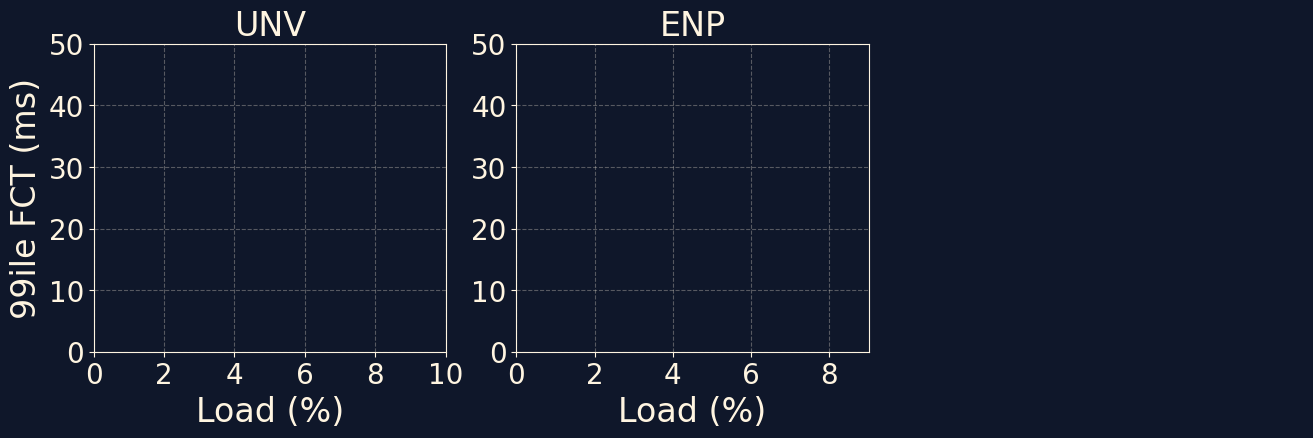

In [35]:
import matplotlib.pyplot as plt
import numpy as np

my_scheme_list = []

plottitledict = {"unv1":"UNV","prv1":"ENP","cluster_a":"DB","cluster_b":"WS","cluster_c":"HD"}
plotlabeldict = {"dringsu2":"Starfish","dringsu2e":"Starfish (Oblivious)*","leafspine":"Leaf-Spine*","df2augalg":"Dragonfly","rrgsu2":"Jellyfish","dringecmp":"DRing+SRT","dringwcmpecmp":"DRing+WCMP*","dringfatpaths":"DRing+FatPaths","dringfhi":"DRing+VLB","dringracke1four":"DRing+SMORE"}
plotxlimdict = {"unv1":None,"prv1":9,"cluster_a":25,"cluster_b":35,"cluster_c":40}
plotmarkers = ['o', 's', '^', 'v', 'D', 'P', '*', 'X', 'h', '1']
plotcolordict = {"dringsu2":"#f35b04","dringsu2e":"#f7b801","leafspine":"#07f49e","df2augalg":"#9683ec","rrgsu2":"#5d16a6","dringecmp":"#4cc9f0","dringwcmpecmp":"#4895ef","dringfatpaths":"#4361ee","dringfhi":"#3f37c9","dringracke1four":"#3a0ca3"}
plotxticksdict = {"unv1":[0,2,4,6,8,10],"prv1":[0,2,4,6,8],"cluster_a":[0,5,10,15,20,25],"cluster_b":[0,5,10,15,20,25,30,35],"cluster_c":[0,10,20,30,40]}

bg_color = "#0F172A"
text_color = "#FFF5E1"

plotdatadict = dict()
sumfile = "fct_summary.txt"

with open(sumfile, "r") as f:
    for line in f:
        tokens = line.split()
        outfile = tokens[0]
        outfiletokens = outfile.split("/")
        cm = outfiletokens[0]

        avg = float(tokens[1])
        p50 = float(tokens[2])
        p99 = float(tokens[3])
        p9999 = float(tokens[4])

        if cm not in plotdatadict:
            plotdatadict[cm] = dict()

        plotdatadict[cm][outfile] = p99


nr = 1
nc = len(cm_list)

fig, axs = plt.subplots(nr, nc, figsize=(nc * 5, nr * 4))

fig.patch.set_facecolor(bg_color)

if nc == 1:
    axs = [axs]

for ic, cm in enumerate(cm_list):
    ax = axs[ic]
    ax.set_facecolor(bg_color)

    for isc, scheme in enumerate(my_scheme_list):
        fct_list = []

        for load in load_list_dict[cm]:
            fct_list_allseeds = []

            for seed in seed_list:
                outfile = f"{cm}/outfiles/{scheme}_load{load}_seed{seed}.out"
                p99 = plotdatadict[cm][outfile]
                fct_list_allseeds.append(p99)

            fct_list.append(fct_list_allseeds)

        means = [sum(x) / len(x) for x in fct_list]
        yerr_lower = [sum(x) / len(x) - min(x) for x in fct_list]
        yerr_upper = [max(x) - sum(x) / len(x) for x in fct_list]

        label = plotlabeldict[scheme] if ic == 0 else None

        ax.errorbar(
            load_list_dict[cm],
            means,
            yerr=[yerr_lower, yerr_upper],
            alpha=0.9,
            markersize=10,
            marker=plotmarkers[isc],
            color=plotcolordict[scheme],
            capsize=4,
            linewidth=2,
            label=label,
        )

    ax.set_xlabel("Load (%)", fontsize=24, color=text_color)

    if ic == 0:
        ax.set_ylabel("99ile FCT (ms)", fontsize=24, color=text_color)

    ax.set_xlim(0, plotxlimdict[cm])
    ax.set_ylim(0, 50)
    ax.set_xticks(plotxticksdict[cm])
    ax.set_title(plottitledict[cm], fontsize=24, color=text_color)

    ax.tick_params(axis="both", labelsize=20, colors=text_color)

    ax.grid(True, linestyle="--", alpha=0.3, color=text_color)

    for spine in ax.spines.values():
        spine.set_color(text_color)

legend = fig.legend(
    loc="center right",
    ncol=1,
    fontsize=22,
    bbox_to_anchor=(1.35, 0.5),
    frameon=False,
)

for text in legend.get_texts():
    text.set_color(text_color)

plt.savefig(f"talk_capacity_empty.pdf", dpi=600, bbox_inches='tight')

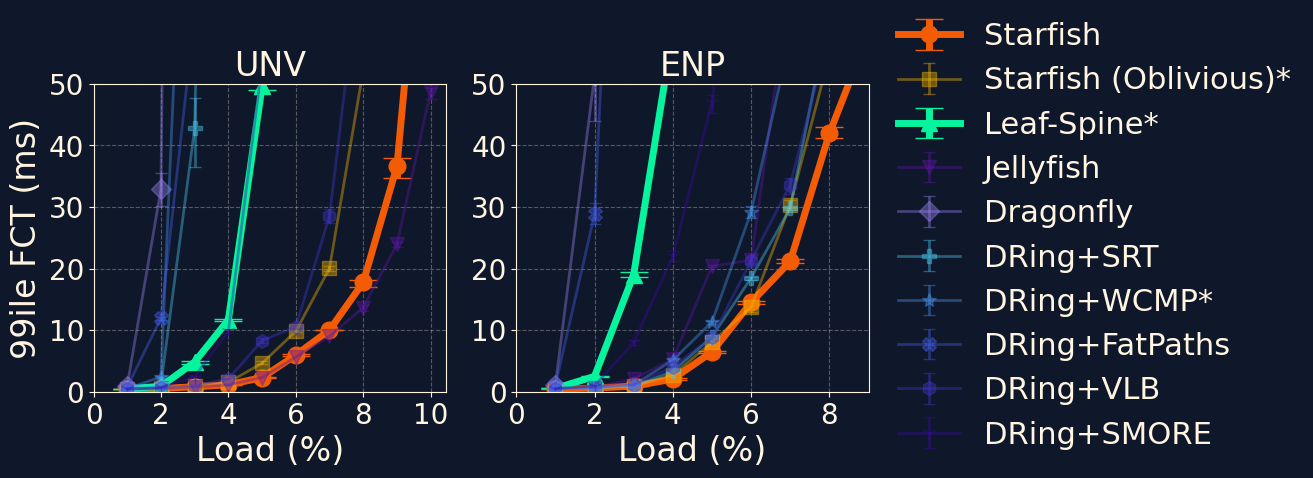

In [49]:
import matplotlib.pyplot as plt
import numpy as np

plottitledict = {"unv1":"UNV","prv1":"ENP","cluster_a":"DB","cluster_b":"WS","cluster_c":"HD"}
plotlabeldict = {"dringsu2":"Starfish","dringsu2e":"Starfish (Oblivious)*","leafspine":"Leaf-Spine*","df2augalg":"Dragonfly","rrgsu2":"Jellyfish","dringecmp":"DRing+SRT","dringwcmpecmp":"DRing+WCMP*","dringfatpaths":"DRing+FatPaths","dringfhi":"DRing+VLB","dringracke1four":"DRing+SMORE"}
plotxlimdict = {"unv1":None,"prv1":9,"cluster_a":25,"cluster_b":35,"cluster_c":40}
plotmarkers = ['o', 's', '^', 'v', 'D', 'P', '*', 'X', 'h', '1']
plotcolordict = {"dringsu2":"#f35b04","dringsu2e":"#f7b801","leafspine":"#07f49e","df2augalg":"#9683ec","rrgsu2":"#5d16a6","dringecmp":"#4cc9f0","dringwcmpecmp":"#4895ef","dringfatpaths":"#4361ee","dringfhi":"#3f37c9","dringracke1four":"#3a0ca3"}
plotxticksdict = {"unv1":[0,2,4,6,8,10],"prv1":[0,2,4,6,8],"cluster_a":[0,5,10,15,20,25],"cluster_b":[0,5,10,15,20,25,30,35],"cluster_c":[0,10,20,30,40]}

bg_color = "#0F172A"
text_color = "#FFF5E1"

plotdatadict = dict()
sumfile = "fct_summary.txt"

with open(sumfile, "r") as f:
    for line in f:
        tokens = line.split()
        outfile = tokens[0]
        outfiletokens = outfile.split("/")
        cm = outfiletokens[0]

        avg = float(tokens[1])
        p50 = float(tokens[2])
        p99 = float(tokens[3])
        p9999 = float(tokens[4])

        if cm not in plotdatadict:
            plotdatadict[cm] = dict()

        plotdatadict[cm][outfile] = p99


nr = 1
nc = len(cm_list)

fig, axs = plt.subplots(nr, nc, figsize=(nc * 5, nr * 4))

fig.patch.set_facecolor(bg_color)

if nc == 1:
    axs = [axs]

for ic, cm in enumerate(cm_list):
    ax = axs[ic]
    ax.set_facecolor(bg_color)

    for isc, scheme in enumerate(scheme_list):
        fct_list = []

        for load in load_list_dict[cm]:
            fct_list_allseeds = []

            for seed in seed_list:
                outfile = f"{cm}/outfiles/{scheme}_load{load}_seed{seed}.out"
                p99 = plotdatadict[cm][outfile]
                fct_list_allseeds.append(p99)

            fct_list.append(fct_list_allseeds)

        means = [sum(x) / len(x) for x in fct_list]
        yerr_lower = [sum(x) / len(x) - min(x) for x in fct_list]
        yerr_upper = [max(x) - sum(x) / len(x) for x in fct_list]

        label = plotlabeldict[scheme] if ic == 0 else None

        if scheme != "dringsu2" and scheme != "leafspine":
            ax.errorbar(
                load_list_dict[cm],
                means,
                yerr=[yerr_lower, yerr_upper],
                alpha=0.4,
                markersize=10,
                marker=plotmarkers[isc],
                color=plotcolordict[scheme],
                capsize=4,
                linewidth=2,
                label=label,
            )
        else:
            ax.errorbar(
                load_list_dict[cm],
                means,
                yerr=[yerr_lower, yerr_upper],
                alpha=1,
                markersize=12,
                marker=plotmarkers[isc],
                color=plotcolordict[scheme],
                capsize=10,
                linewidth=5,
                label=label,
            )

    ax.set_xlabel("Load (%)", fontsize=24, color=text_color)

    if ic == 0:
        ax.set_ylabel("99ile FCT (ms)", fontsize=24, color=text_color)

    ax.set_xlim(0, plotxlimdict[cm])
    ax.set_ylim(0, 50)
    ax.set_xticks(plotxticksdict[cm])
    ax.set_title(plottitledict[cm], fontsize=24, color=text_color)

    ax.tick_params(axis="both", labelsize=20, colors=text_color)

    ax.grid(True, linestyle="--", alpha=0.3, color=text_color)

    for spine in ax.spines.values():
        spine.set_color(text_color)

legend = fig.legend(
    loc="center right",
    ncol=1,
    fontsize=22,
    bbox_to_anchor=(1.35, 0.5),
    frameon=False,
)

for text in legend.get_texts():
    text.set_color(text_color)

plt.savefig(f"talk_capacity_starfish.pdf", dpi=600, bbox_inches='tight')

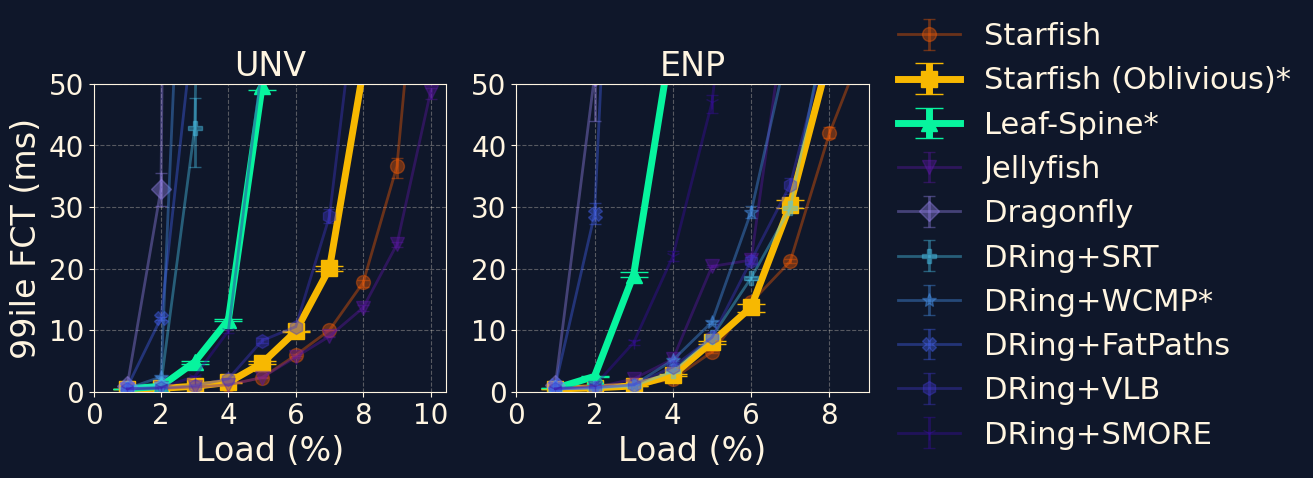

In [50]:
import matplotlib.pyplot as plt
import numpy as np

plottitledict = {"unv1":"UNV","prv1":"ENP","cluster_a":"DB","cluster_b":"WS","cluster_c":"HD"}
plotlabeldict = {"dringsu2":"Starfish","dringsu2e":"Starfish (Oblivious)*","leafspine":"Leaf-Spine*","df2augalg":"Dragonfly","rrgsu2":"Jellyfish","dringecmp":"DRing+SRT","dringwcmpecmp":"DRing+WCMP*","dringfatpaths":"DRing+FatPaths","dringfhi":"DRing+VLB","dringracke1four":"DRing+SMORE"}
plotxlimdict = {"unv1":None,"prv1":9,"cluster_a":25,"cluster_b":35,"cluster_c":40}
plotmarkers = ['o', 's', '^', 'v', 'D', 'P', '*', 'X', 'h', '1']
plotcolordict = {"dringsu2":"#f35b04","dringsu2e":"#f7b801","leafspine":"#07f49e","df2augalg":"#9683ec","rrgsu2":"#5d16a6","dringecmp":"#4cc9f0","dringwcmpecmp":"#4895ef","dringfatpaths":"#4361ee","dringfhi":"#3f37c9","dringracke1four":"#3a0ca3"}
plotxticksdict = {"unv1":[0,2,4,6,8,10],"prv1":[0,2,4,6,8],"cluster_a":[0,5,10,15,20,25],"cluster_b":[0,5,10,15,20,25,30,35],"cluster_c":[0,10,20,30,40]}

bg_color = "#0F172A"
text_color = "#FFF5E1"

plotdatadict = dict()
sumfile = "fct_summary.txt"

with open(sumfile, "r") as f:
    for line in f:
        tokens = line.split()
        outfile = tokens[0]
        outfiletokens = outfile.split("/")
        cm = outfiletokens[0]

        avg = float(tokens[1])
        p50 = float(tokens[2])
        p99 = float(tokens[3])
        p9999 = float(tokens[4])

        if cm not in plotdatadict:
            plotdatadict[cm] = dict()

        plotdatadict[cm][outfile] = p99


nr = 1
nc = len(cm_list)

fig, axs = plt.subplots(nr, nc, figsize=(nc * 5, nr * 4))

fig.patch.set_facecolor(bg_color)

if nc == 1:
    axs = [axs]

for ic, cm in enumerate(cm_list):
    ax = axs[ic]
    ax.set_facecolor(bg_color)

    for isc, scheme in enumerate(scheme_list):
        fct_list = []

        for load in load_list_dict[cm]:
            fct_list_allseeds = []

            for seed in seed_list:
                outfile = f"{cm}/outfiles/{scheme}_load{load}_seed{seed}.out"
                p99 = plotdatadict[cm][outfile]
                fct_list_allseeds.append(p99)

            fct_list.append(fct_list_allseeds)

        means = [sum(x) / len(x) for x in fct_list]
        yerr_lower = [sum(x) / len(x) - min(x) for x in fct_list]
        yerr_upper = [max(x) - sum(x) / len(x) for x in fct_list]

        label = plotlabeldict[scheme] if ic == 0 else None

        if scheme != "dringsu2e" and scheme != "leafspine":
            ax.errorbar(
                load_list_dict[cm],
                means,
                yerr=[yerr_lower, yerr_upper],
                alpha=0.4,
                markersize=10,
                marker=plotmarkers[isc],
                color=plotcolordict[scheme],
                capsize=4,
                linewidth=2,
                label=label,
            )
        else:
            ax.errorbar(
                load_list_dict[cm],
                means,
                yerr=[yerr_lower, yerr_upper],
                alpha=1,
                markersize=12,
                marker=plotmarkers[isc],
                color=plotcolordict[scheme],
                capsize=10,
                linewidth=5,
                label=label,
            )

    ax.set_xlabel("Load (%)", fontsize=24, color=text_color)

    if ic == 0:
        ax.set_ylabel("99ile FCT (ms)", fontsize=24, color=text_color)

    ax.set_xlim(0, plotxlimdict[cm])
    ax.set_ylim(0, 50)
    ax.set_xticks(plotxticksdict[cm])
    ax.set_title(plottitledict[cm], fontsize=24, color=text_color)

    ax.tick_params(axis="both", labelsize=20, colors=text_color)

    ax.grid(True, linestyle="--", alpha=0.3, color=text_color)

    for spine in ax.spines.values():
        spine.set_color(text_color)

legend = fig.legend(
    loc="center right",
    ncol=1,
    fontsize=22,
    bbox_to_anchor=(1.35, 0.5),
    frameon=False,
)

for text in legend.get_texts():
    text.set_color(text_color)

plt.savefig(f"talk_capacity_starfishoblivious.pdf", dpi=600, bbox_inches='tight')

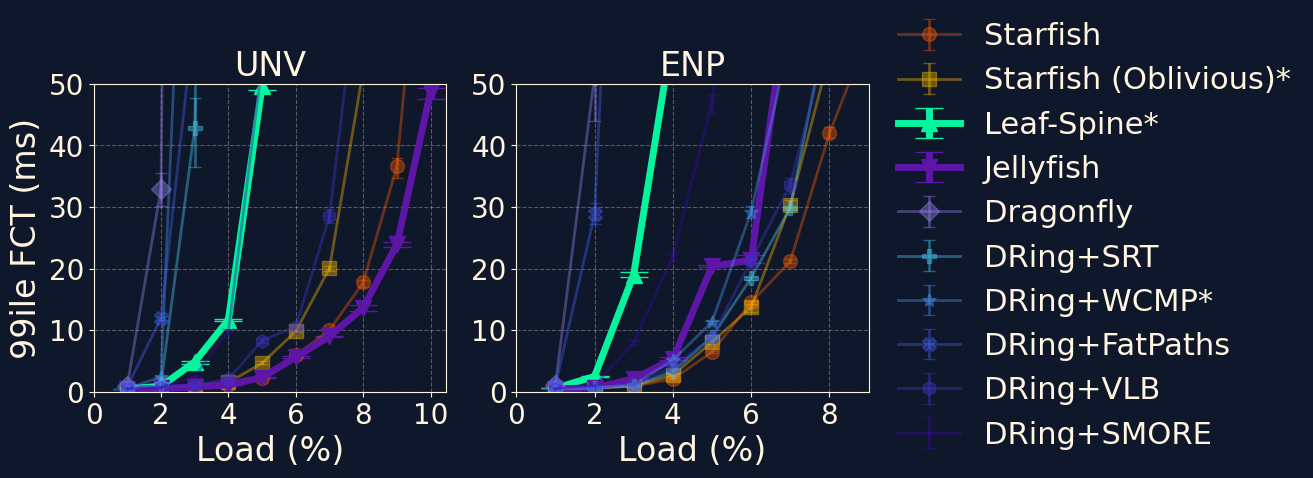

In [51]:
import matplotlib.pyplot as plt
import numpy as np

plottitledict = {"unv1":"UNV","prv1":"ENP","cluster_a":"DB","cluster_b":"WS","cluster_c":"HD"}
plotlabeldict = {"dringsu2":"Starfish","dringsu2e":"Starfish (Oblivious)*","leafspine":"Leaf-Spine*","df2augalg":"Dragonfly","rrgsu2":"Jellyfish","dringecmp":"DRing+SRT","dringwcmpecmp":"DRing+WCMP*","dringfatpaths":"DRing+FatPaths","dringfhi":"DRing+VLB","dringracke1four":"DRing+SMORE"}
plotxlimdict = {"unv1":None,"prv1":9,"cluster_a":25,"cluster_b":35,"cluster_c":40}
plotmarkers = ['o', 's', '^', 'v', 'D', 'P', '*', 'X', 'h', '1']
plotcolordict = {"dringsu2":"#f35b04","dringsu2e":"#f7b801","leafspine":"#07f49e","df2augalg":"#9683ec","rrgsu2":"#5d16a6","dringecmp":"#4cc9f0","dringwcmpecmp":"#4895ef","dringfatpaths":"#4361ee","dringfhi":"#3f37c9","dringracke1four":"#3a0ca3"}
plotxticksdict = {"unv1":[0,2,4,6,8,10],"prv1":[0,2,4,6,8],"cluster_a":[0,5,10,15,20,25],"cluster_b":[0,5,10,15,20,25,30,35],"cluster_c":[0,10,20,30,40]}

bg_color = "#0F172A"
text_color = "#FFF5E1"

plotdatadict = dict()
sumfile = "fct_summary.txt"

with open(sumfile, "r") as f:
    for line in f:
        tokens = line.split()
        outfile = tokens[0]
        outfiletokens = outfile.split("/")
        cm = outfiletokens[0]

        avg = float(tokens[1])
        p50 = float(tokens[2])
        p99 = float(tokens[3])
        p9999 = float(tokens[4])

        if cm not in plotdatadict:
            plotdatadict[cm] = dict()

        plotdatadict[cm][outfile] = p99


nr = 1
nc = len(cm_list)

fig, axs = plt.subplots(nr, nc, figsize=(nc * 5, nr * 4))

fig.patch.set_facecolor(bg_color)

if nc == 1:
    axs = [axs]

for ic, cm in enumerate(cm_list):
    ax = axs[ic]
    ax.set_facecolor(bg_color)

    for isc, scheme in enumerate(scheme_list):
        fct_list = []

        for load in load_list_dict[cm]:
            fct_list_allseeds = []

            for seed in seed_list:
                outfile = f"{cm}/outfiles/{scheme}_load{load}_seed{seed}.out"
                p99 = plotdatadict[cm][outfile]
                fct_list_allseeds.append(p99)

            fct_list.append(fct_list_allseeds)

        means = [sum(x) / len(x) for x in fct_list]
        yerr_lower = [sum(x) / len(x) - min(x) for x in fct_list]
        yerr_upper = [max(x) - sum(x) / len(x) for x in fct_list]

        label = plotlabeldict[scheme] if ic == 0 else None

        if scheme != "rrgsu2" and scheme != "leafspine":
            ax.errorbar(
                load_list_dict[cm],
                means,
                yerr=[yerr_lower, yerr_upper],
                alpha=0.4,
                markersize=10,
                marker=plotmarkers[isc],
                color=plotcolordict[scheme],
                capsize=4,
                linewidth=2,
                label=label,
            )
        else:
            ax.errorbar(
                load_list_dict[cm],
                means,
                yerr=[yerr_lower, yerr_upper],
                alpha=1,
                markersize=12,
                marker=plotmarkers[isc],
                color=plotcolordict[scheme],
                capsize=10,
                linewidth=5,
                label=label,
            )

    ax.set_xlabel("Load (%)", fontsize=24, color=text_color)

    if ic == 0:
        ax.set_ylabel("99ile FCT (ms)", fontsize=24, color=text_color)

    ax.set_xlim(0, plotxlimdict[cm])
    ax.set_ylim(0, 50)
    ax.set_xticks(plotxticksdict[cm])
    ax.set_title(plottitledict[cm], fontsize=24, color=text_color)

    ax.tick_params(axis="both", labelsize=20, colors=text_color)

    ax.grid(True, linestyle="--", alpha=0.3, color=text_color)

    for spine in ax.spines.values():
        spine.set_color(text_color)

legend = fig.legend(
    loc="center right",
    ncol=1,
    fontsize=22,
    bbox_to_anchor=(1.35, 0.5),
    frameon=False,
)

for text in legend.get_texts():
    text.set_color(text_color)

plt.savefig(f"talk_capacity_jellyfish.pdf", dpi=600, bbox_inches='tight')